# 09 - Temporal Drift Validation

In [1]:
import sys, os
sys.path.insert(0, r"D:\Quantum Credit Card Fraud Detection")
os.chdir(r"D:\Quantum Credit Card Fraud Detection")
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 100
plt.style.use("seaborn-v0_8-darkgrid")


## Overview

Chronological / rolling-window forward-chaining validation (spec sections 15-16): trains on
an earlier time window, tests on the next, and slides forward — measuring PR-AUC degradation
over (synthetic) time, plus PSI/KS drift statistics on the Amount distribution between the
first and last windows.

In [2]:
from src.experiments.run_temporal import run_temporal_experiment

result = run_temporal_experiment(dataset_key="ulb", model_name="xgboost", use_synthetic=True,
                                  n_folds=5, random_seed=42)
fold_results = result["fold_results"]
print(result["degradation_summary"])
print("Amount PSI:", result["amount_psi"], "-> status:", result["drift_status"])


2026-09-14 01:52:52 | WARNING  | experiments.run_classical | Using SYNTHETIC data for 'ulb' (development/testing only).


2026-09-14 01:53:05 | INFO     | experiments.run_temporal | window 0: pr_auc=0.988 recall=0.778


2026-09-14 01:53:05 | INFO     | experiments.run_temporal | window 1: pr_auc=0.792 recall=0.600


2026-09-14 01:53:05 | INFO     | experiments.run_temporal | window 2: pr_auc=0.910 recall=0.667


2026-09-14 01:53:05 | INFO     | experiments.run_temporal | window 3: pr_auc=0.920 recall=0.750


2026-09-14 01:53:05 | INFO     | experiments.run_temporal | Degradation summary: {'pr_auc_first': 0.9882716049382716, 'pr_auc_last': 0.920405982905983, 'pr_auc_delta': -0.06786562203228863}


2026-09-14 01:53:05 | INFO     | experiments.run_temporal | Amount-distribution PSI (first vs last window) = 0.0170 -> status=NORMAL


{'pr_auc_first': 0.9882716049382716, 'pr_auc_last': 0.920405982905983, 'pr_auc_delta': -0.06786562203228863}
Amount PSI: 0.017044542331944607 -> status: NORMAL


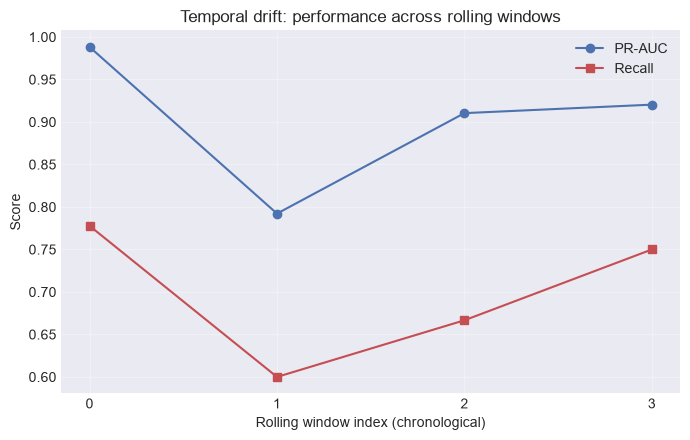

In [3]:
windows = [f.window_index for f in fold_results]
pr_aucs = [f.metrics.pr_auc for f in fold_results]
recalls = [f.metrics.recall for f in fold_results]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(windows, pr_aucs, marker="o", label="PR-AUC", color="#4C72B0")
ax.plot(windows, recalls, marker="s", label="Recall", color="#C44E52")
ax.set_xlabel("Rolling window index (chronological)")
ax.set_ylabel("Score")
ax.set_title("Temporal drift: performance across rolling windows")
ax.set_xticks(windows)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\09_temporal_drift.png")
plt.show()


In [4]:
fold_df = pd.DataFrame([{
    "window": f.window_index, "n_train": f.n_train, "n_test": f.n_test,
    "pr_auc": f.metrics.pr_auc, "recall": f.metrics.recall, "fpr": f.metrics.fpr,
} for f in fold_results])
fold_df


,window,n_train,n_test,pr_auc,recall,fpr
0,0,3000,500,0.988272,0.777778,0.000000
1,1,3000,500,0.792203,0.600000,0.000000
2,2,3000,500,0.910417,0.666667,0.002024
3,3,3000,500,0.920406,0.750000,0.000000
